Obs: Converter em um arquivo .py para rodar.

# Importações

In [2]:
import abc

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import warnings

from matplotlib.ticker import FuncFormatter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from pyESN import ESN

from pyswarms.single import GlobalBestPSO
from sklearn.model_selection import TimeSeriesSplit, train_test_split

from anneal import Annealer

MODELOS = ["ESN", "MLP", "RF", "XGBoost"]
SEEDS = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
OTIMIZADORES = ["PSO", "SA"]
N_ITER = 15
N_SOLUCOES = 15
K_FOLDS = 5

warnings.filterwarnings('ignore')


def reset_seed(rnd_seed):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


def calcular_rrmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = root_mean_squared_error(y_true, y_pred)

    mean_y_true = np.mean(y_true)

    rrmse = rmse / mean_y_true
    return rrmse


reset_seed(100)


# Configuração dos Otimizadores
## Otimizador Base

In [3]:
class Otimizador:

    @abc.abstractmethod
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        reset_seed(seed)
        self.nome_modelo = None
        self.dataset = dataset
        self.features = features
        self.seed = seed
        self.n_solucoes = n_solucoes
        self.n_iteracoes = n_iteracoes
        self.solucoes = []
        self.iteracoes = []

    @abc.abstractmethod
    def run(self):
        pass

    @abc.abstractmethod
    def run_objective_function(self, parametros):
        pass

    def objective_function(self, modelo):
        cvs_todos = []

        for campus, dados in self.dataset.groupby("CAMPUS"):
            previsoes = []
            valores_reais = []

            for i_treino, i_teste in TimeSeriesSplit(n_splits=K_FOLDS, test_size=1).split(dados):
                x = dados[self.features]
                y = dados["CONSUMO"]

                x_treino = x.iloc[i_treino]
                y_treino = y.iloc[i_treino]
                x_teste = x.iloc[i_teste]
                y_teste = y.iloc[i_teste]

                modelo.fit(x_treino, y_treino)

                y_previsto = modelo.predict(x_teste)[0]
                previsoes.append(y_previsto)
                valores_reais.append(y_teste)

            cvs_todos.append(calcular_rrmse(valores_reais, previsoes).mean())

        return np.array(cvs_todos).mean()

    def iteracoes_dataframe(self):
        df = pd.DataFrame()
        for i in range(len(self.iteracoes)):
            part = self.iteracoes[i]
            df = pd.concat([df, pd.DataFrame.from_dict(part.to_dict(), orient='index').T], ignore_index=True)
        return df

    def salvar_csv(self):
        pd_df = self.iteracoes_dataframe()
        pd_df.to_csv(f"resultados/otimização - regressão/{self.nome_modelo} SEED {self.seed}.csv", sep=";", decimal=".",
                     index=True)


### ESN

In [4]:
class SolucaoESN:
    def __init__(self):
        self.fitness = None
        self.n_reservoirs = 0
        self.sparsity = 0
        self.spectral_radius = 0

    def to_dict(self):
        return {
            "Reservoirs": self.n_reservoirs,
            "Sparsity": self.sparsity,
            "Spectral Radius": self.spectral_radius,
            "Fitness": self.fitness,
        }

### MLP

In [5]:
class SolucaoMLP:
    def __init_(self):
        self.fitness = None
        self.hidden_layer_sizes = 0
        self.alpha = 0
        self.activation = None

    def to_dict(self):
        return {
            "Hidden Layers": self.hidden_layer_sizes,
            "Alpha": self.alpha,
            "Activation": self.activation,
            "Fitness": self.fitness,
        }


### Random Forest

In [6]:
class SolucaoRF:
    def __init_(self):
        self.fitness = None
        self.estimators = 0
        self.max_depth = 0
        self.min_samples_split = 0
        self.min_samples_leaf = 0

    def to_dict(self):
        return {
            "N_estimators": self.estimators,
            "Max_depth": self.max_depth,
            "Min_samples_split": self.min_samples_split,
            "Min_samples_leaf": self.min_samples_leaf,
            "Fitness": self.fitness,
        }

### XGBoost

In [7]:
class SolucaoXGB:
    def __init_(self):
        self.fitness = None
        self.estimators = 0
        self.max_depth = 0
        self.booster = None
        self.reg_lambda = 0
        self.reg_alpha = 0

    def to_dict(self):
        return {
            "N_estimators": self.estimators,
            "Max_depth": self.max_depth,
            "Booster": self.booster,
            "Lambda": self.reg_lambda,
            "Alpha": self.reg_alpha,
            "Fitness": self.fitness,
        }


## Simulated Annealing (SA)

In [8]:
class SimulatedAnneal(Annealer):
    def __init__(self, params, objective_function, max_iter):
        self.params = params
        self.objective_function = objective_function
        super().__init__(self.random_initial_state())
        self.steps = max_iter
        self.Tmin = 0.0001
        self.Tmax = 1
        self.updates = 0
        self.anneal()

    def random_initial_state(self):
        initial_state = {}
        for key in self.params.keys():
            initial_state[key] = random.choice(self.params[key])
        return initial_state

    def move(self):
        atual = self.state
        for key in self.params.keys():
            valor = atual[key]
            opcoes = len(self.params[key])
            if opcoes <= 2:
                self.state[key] = random.choice(self.params[key])
            else:
                intervalo = int(np.round(self.T * opcoes))
                diferencas = np.abs(np.array(self.params[key]) - valor)
                index = np.argmin(diferencas)
                inicio = max(0, index - intervalo)
                fim = min(opcoes - 1, index + intervalo)
                if inicio == fim:
                    self.state[key] = self.params[key][inicio]
                else:
                    self.state[key] = self.params[key][random.choice(range(inicio, fim))]

    def energy(self):
        return self.objective_function(self.state)

### ESN

In [9]:
class SAESN(Otimizador):

    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-ESN"
        self.run()

    def run(self):
        parametros = {
            "n_reservoirs": range(10, 400),
            "sparsity": np.arange(0.001, 0.8, 0.001),
            "spectral_radius": np.arange(0.001, 0.8, 0.001),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoESN()
        solucao.n_reservoirs = int(parametros["n_reservoirs"])
        solucao.sparsity = np.round(parametros["sparsity"], 4)
        solucao.spectral_radius = np.round(parametros["spectral_radius"], 4)

        search = list(filter(lambda par:
                             par.n_reservoirs == solucao.n_reservoirs and
                             par.sparsity == solucao.sparsity and
                             par.spectral_radius == solucao.spectral_radius, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = ESN(n_inputs=self.dataset[self.features].shape[1],
                         n_outputs=1,
                         n_reservoir=solucao.n_reservoirs,
                         sparsity=solucao.sparsity,
                         spectral_radius=solucao.spectral_radius,
                         random_state=self.seed)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

### MLP

In [10]:
class SAMLP(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-MLP"
        self.ACTIVATIONS = ["identity", "logistic", "tanh", "relu"]
        self.run()

    def run(self):
        parametros = {
            "hidden_layer_sizes": range(10, 400),
            "alpha": np.arange(0, 1, 0.01),
            "activation": range(0, 4),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoMLP()
        solucao.hidden_layer_sizes = int(parametros["hidden_layer_sizes"])
        solucao.alpha = round(parametros["alpha"], 4)
        solucao.activation = self.ACTIVATIONS[int(parametros["activation"])]

        search = list(filter(lambda par:
                             par.hidden_layer_sizes == solucao.hidden_layer_sizes and
                             par.alpha == solucao.alpha and
                             par.activation == solucao.activation, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = MLPRegressor(hidden_layer_sizes=(solucao.hidden_layer_sizes,),
                                  activation=solucao.activation,
                                  alpha=solucao.alpha,
                                  random_state=self.seed)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

### Random Forest


In [11]:
class SARF(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-RF"
        self.run()

    def run(self):
        parametros = {
            "estimators": range(10, 400),
            "max_depth": range(10, 400),
            "min_samples_split": range(2, 50),
            "min_samples_leaf": range(2, 50),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoRF()
        solucao.estimators = int(parametros["estimators"])
        solucao.max_depth = int(parametros["max_depth"])
        solucao.min_samples_split = int(parametros["min_samples_split"])
        solucao.min_samples_leaf = int(parametros["min_samples_leaf"])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.min_samples_split == solucao.min_samples_split and
                             par.min_samples_leaf == solucao.min_samples_leaf, self.solucoes))

        if search:
            solucao = search[0]

        else:
            modelo = RandomForestRegressor(random_state=self.seed,
                                           n_estimators=solucao.estimators,
                                           max_depth=solucao.max_depth,
                                           min_samples_split=solucao.min_samples_split,
                                           min_samples_leaf=solucao.min_samples_leaf)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness


### XGBoost

In [12]:
class SAXGB(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "SA-XGBoost"
        self.BOOSTERS = ["gbtree", "gblinear", "dart"]
        self.run()

    def run(self):
        parametros = {
            "estimators": range(10, 400),
            "max_depth": range(10, 400),
            "booster": range(0, 2),
            "reg_lambda": np.arange(0, 1, 0.005),
            "reg_alpha": np.arange(0, 1, 0.005),
        }
        SimulatedAnneal(parametros, self.run_objective_function, max_iter=self.n_iteracoes * self.n_solucoes)

    def run_objective_function(self, parametros):
        solucao = SolucaoXGB()
        solucao.estimators = int(parametros["estimators"])
        solucao.max_depth = int(parametros["max_depth"])
        solucao.booster = self.BOOSTERS[int(parametros["booster"])]
        solucao.reg_lambda = float(parametros["reg_lambda"])
        solucao.reg_alpha = float(parametros["reg_alpha"])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.booster == solucao.booster and
                             par.reg_lambda == solucao.reg_lambda and
                             par.reg_alpha == solucao.reg_alpha, self.solucoes))

        if search:
            solucao = search[0]

        else:
            updater = "coord_descent" if solucao.booster == "gblinear" else None
            modelo = XGBRegressor(random_state=self.seed,
                                  n_estimators=solucao.estimators,
                                  max_depth=solucao.max_depth,
                                  booster=solucao.booster,
                                  reg_lambda=solucao.reg_lambda,
                                  reg_alpha=solucao.reg_alpha,
                                  updater=updater)

            solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return solucao.fitness

## Particle Swarm Optimization (PSO)

### ESN

In [13]:
class PSOESN(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-ESN"
        self.run()

    def run(self):
        lower_bound = [10, 0.001, 0.001]
        uppper_bound = [400, 0.8, 0.8]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=3,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoESN()
        solucao.n_reservoirs = int(particle_arr[0])
        solucao.sparsity = round(particle_arr[1], 4)
        solucao.spectral_radius = round(particle_arr[2], 4)

        search = list(filter(lambda par:
                             par.n_reservoirs == solucao.n_reservoirs and
                             par.sparsity == solucao.sparsity and
                             par.spectral_radius == solucao.spectral_radius, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = ESN(n_inputs=self.dataset[self.features].shape[1],
                     n_outputs=1,
                     n_reservoir=solucao.n_reservoirs,
                     sparsity=solucao.sparsity,
                     spectral_radius=solucao.spectral_radius,
                     random_state=self.seed)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness


### MLP

In [14]:
class PSOMLP(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-MLP"
        self.ACTIVATIONS = ["identity", "logistic", "tanh", "relu"]
        self.run()

    def run(self):
        lower_bound = [10, 0, 0]
        uppper_bound = [400, 1.0, 4]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=3,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoMLP()
        solucao.hidden_layer_sizes = int(particle_arr[0])
        solucao.alpha = particle_arr[1]
        solucao.activation = self.ACTIVATIONS[int(particle_arr[2])]

        search = list(filter(lambda par:
                             par.hidden_layer_sizes == solucao.hidden_layer_sizes and
                             par.alpha == solucao.alpha and
                             par.activation == solucao.activation, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = MLPRegressor(hidden_layer_sizes=(solucao.hidden_layer_sizes,),
                              activation=solucao.activation,
                              alpha=solucao.alpha,
                              random_state=self.seed)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness

### Random Forest


In [15]:
class PSORF(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-RF"
        self.run()

    def run(self):
        lower_bound = [10, 10, 2, 2]
        uppper_bound = [400, 400, 50, 50]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=4,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoRF()
        solucao.estimators = int(particle_arr[0])
        solucao.max_depth = int(particle_arr[1])
        solucao.min_samples_split = int(particle_arr[2])
        solucao.min_samples_leaf = int(particle_arr[3])

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.min_samples_split == solucao.min_samples_split and
                             par.min_samples_leaf == solucao.min_samples_leaf, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        modelo = RandomForestRegressor(random_state=self.seed,
                                       n_estimators=solucao.estimators,
                                       max_depth=solucao.max_depth,
                                       min_samples_split=solucao.min_samples_split,
                                       min_samples_leaf=solucao.min_samples_leaf)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness


### XGBoost

In [16]:
class PSOXGB(Otimizador):
    def __init__(self, dataset, features, n_solucoes, n_iteracoes, seed):
        super().__init__(dataset, features, n_solucoes, n_iteracoes, seed)
        self.nome_modelo = "PSO-XGBoost"
        self.BOOSTERS = ["gbtree", "gblinear", "dart"]
        self.run()

    def run(self):
        lower_bound = [10, 10, 0, 0, 0]
        uppper_bound = [400, 400, 2, 1, 1]
        bounds = (lower_bound, uppper_bound)

        options = {'c1': 0.5, 'c2': 0.5, 'w': 0.5}
        optimizer = GlobalBestPSO(n_particles=self.n_solucoes,
                                  dimensions=5,
                                  options=options,
                                  bounds=bounds)

        optimizer.optimize(self.get_fitness, iters=self.n_iteracoes)

    def get_fitness(self, parts):
        fit_lst = [self.run_objective_function(parts[j]) for j in range(self.n_solucoes)]

        self.solucoes = sorted(self.solucoes, key=lambda a: a.fitness)
        best = self.solucoes[0]
        self.iteracoes.append(best)
        self.salvar_csv()

        return fit_lst

    def run_objective_function(self, particle_arr):
        solucao = SolucaoXGB()
        solucao.estimators = int(particle_arr[0])
        solucao.max_depth = int(particle_arr[1])
        solucao.booster = self.BOOSTERS[int(particle_arr[2])]
        solucao.reg_lambda = round(particle_arr[3], 4)
        solucao.reg_alpha = round(particle_arr[4], 4)

        search = list(filter(lambda par:
                             par.estimators == solucao.estimators and
                             par.max_depth == solucao.max_depth and
                             par.booster == solucao.booster and
                             par.reg_lambda == solucao.reg_lambda and
                             par.reg_alpha == solucao.reg_alpha, self.solucoes))

        if search:
            self.solucoes.append(search[0])
            return search[0].fitness

        updater = "coord_descent" if solucao.booster == "gblinear" else None
        modelo = XGBRegressor(random_state=self.seed,
                              n_estimators=solucao.estimators,
                              max_depth=solucao.max_depth,
                              booster=solucao.booster,
                              reg_lambda=solucao.reg_lambda,
                              reg_alpha=solucao.reg_alpha,
                              updater=updater)

        solucao.fitness = self.objective_function(modelo)

        self.solucoes.append(solucao)

        return solucao.fitness


# Carregar Datasets

In [17]:
df_consumo = pd.read_csv("./dados/dados_normalizados_lagados.csv", sep=';', decimal='.')

dataframes = []
for campus, dados in df_consumo.groupby("CAMPUS"):
    if len(dados) < 100:
        continue
    treino, teste = train_test_split(dados, test_size=12, shuffle=False)
    dataframes.append(treino)

df_consumo = pd.concat(dataframes, ignore_index=True)

df_features = pd.read_csv("resultados/features/fitness_features_regressao.csv", sep=";", decimal=".")

df_features = df_features.sort_values("RRMSE").head(1).reset_index(drop=True)
df_features = pd.DataFrame(
    columns=str(df_features.iloc[0]["FEATURES"]).replace("(", '').replace(")", '').replace("'", "").split(", "))

df_consumo = df_consumo.sort_values("CAMPUS").sort_values("DATA")
df_features = df_features.columns
df_features

Index(['TEMP_MÉD_MIN_MENS', 'TEMP_MÉD_MÉD_MENS', 'PRECIPITAÇÃO_MÉD_MENS',
       'TEMP_MIN_MAX_MENS', 'TEMP_MAX_MIN_MENS', 'PRECIPITAÇÃO_MIN_MENS',
       'TEMP_MAX_MAX_MENS', 'DIA_DA_SEMANA_dom', 'DIA_DA_SEMANA_seg',
       'DIA_DA_SEMANA_sáb', 'DIA_DA_SEMANA_ter', 'MÊS_abr', 'MÊS_ago',
       'MÊS_fev', 'MÊS_jun', 'MÊS_mai', 'MÊS_nov', 'ANO_2021', 'ANO_2022',
       'ANO_2023', 'ANO_2015', 'ANO_2016', 'ANO_2017', 'ANO_2018', 'ANO_2019',
       'CAMPUS_ASTORGA', 'CAMPUS_CAMPO LARGO', 'CAMPUS_CAPANEMA',
       'CAMPUS_CASCAVEL', 'CAMPUS_CORONEL VIVIDA', 'CAMPUS_CURITIBA',
       'CAMPUS_GOIOERÊ', 'CAMPUS_IVAIPORÃ', 'CAMPUS_JAGUARIAÍVA',
       'CAMPUS_LONDRINA - CENTRO', 'CAMPUS_PALMAS', 'CAMPUS_PARANAGUÁ',
       'CAMPUS_PINHAIS', 'CAMPUS_TELÊMACO BORBA', 'CAMPUS_UMUARAMA',
       'CURSOS_TEC_SUBSEQUENTE', 'CURSOS_GRAD_MATUTINO',
       'CURSOS_GRAD_VESPERTINO', 'CURSOS_GRAD_NOTURNO', 'CURSOS_POS', 'FÉRIAS',
       'COVID', 'LAG_01', 'LAG_02', 'LAG_03', 'LAG_05', 'LAG_07', 'LAG_09'],


# Execução da Otimização

In [ ]:
for seed in SEEDS:
    PSOESN(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    PSOMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    PSORF(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    PSOXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    SAESN(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    SAMLP(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    SARF(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)
    SAXGB(df_consumo, df_features, N_SOLUCOES, N_ITER, seed)


# Optimization Results
## Fitness Evolution

PSO ESN 1000 15
PSO ESN 2000 15
PSO ESN 3000 15
PSO ESN 4000 15
PSO ESN 5000 15
PSO ESN 6000 15
PSO ESN 7000 15
PSO ESN 8000 15
PSO ESN 9000 15
PSO ESN 10000 15


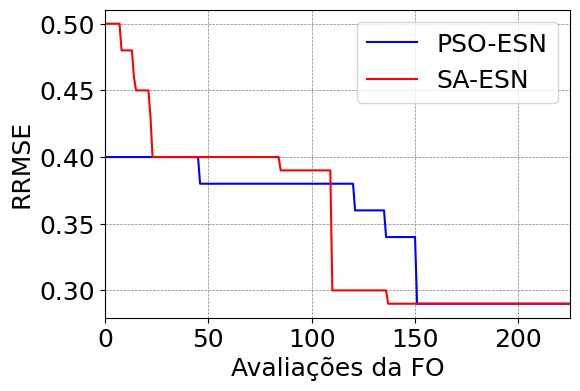

PSO MLP 1000 15
PSO MLP 2000 15
PSO MLP 3000 15
PSO MLP 4000 15
PSO MLP 5000 15
PSO MLP 6000 15
PSO MLP 7000 15
PSO MLP 8000 15
PSO MLP 9000 15
PSO MLP 10000 15


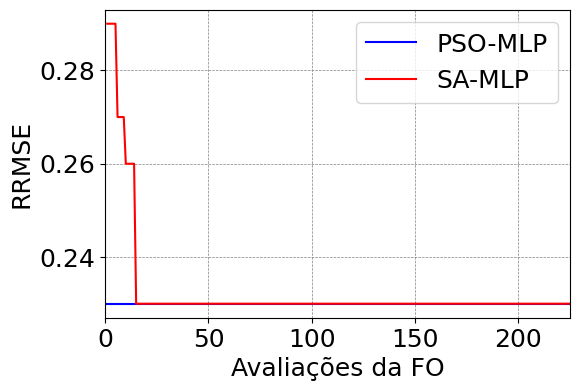

PSO RF 1000 15
PSO RF 2000 15
PSO RF 3000 15
PSO RF 4000 15
PSO RF 5000 15
PSO RF 6000 15
PSO RF 7000 15
PSO RF 8000 15
PSO RF 9000 15
PSO RF 10000 15


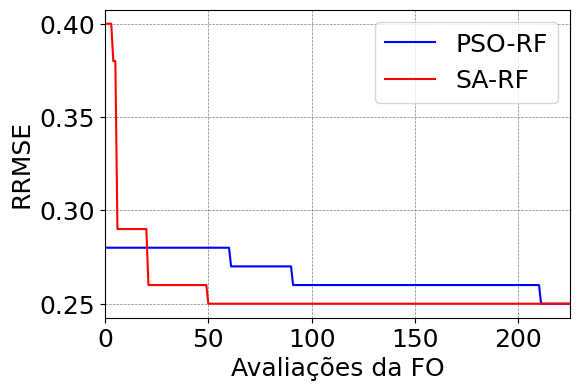

PSO XGBoost 1000 15
PSO XGBoost 2000 15
PSO XGBoost 3000 15
PSO XGBoost 4000 15
PSO XGBoost 5000 15
PSO XGBoost 6000 15
PSO XGBoost 7000 15
PSO XGBoost 8000 15
PSO XGBoost 9000 15
PSO XGBoost 10000 15


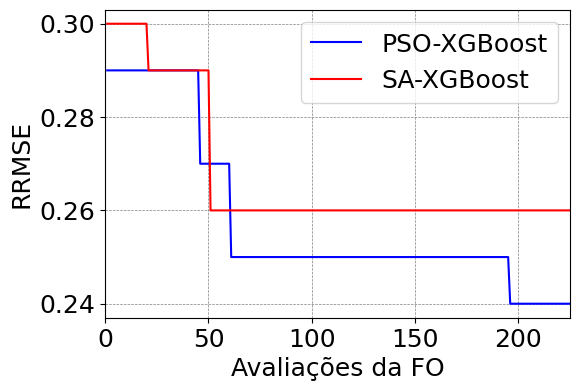

In [6]:
def formatar_y(valor, pos):
    if valor >= 1:
        return f"{valor:.2f}+"
    return f"{valor:.2f}"


for modelo in MODELOS:
    plt.figure(figsize=(6, 4))
    plt.rcParams['xtick.labelsize'] = 18
    plt.rcParams['ytick.labelsize'] = 18
    plt.rcParams.update({'font.size': 18})
    plt.rcParams['axes.prop_cycle'] = plt.cycler(
        color=["blue", "red"])

    for otimizador in OTIMIZADORES:
        df = pd.DataFrame()
        final_fitness = {}
        for seed in SEEDS:
            try:
                novo_df = pd.read_csv(f'resultados/otimização - regressão/{otimizador}-{modelo} SEED {seed}.csv',
                                      sep=";",
                                      decimal=".", header=0)
            except Exception as e:
                continue

            if otimizador == "PSO":
                df[seed] = pd.concat([novo_df["Fitness"].to_frame()] * N_ITER, ignore_index=True)
                df[seed] = sorted(df[seed].values, reverse=True)
            else:
                df[seed] = novo_df["Fitness"]

            final_fitness[seed] = novo_df["Fitness"].iloc[-1]  # Último valor de Fitness para cada seed

        df = np.round(df, decimals=2)
        best_seed = min(final_fitness, key=final_fitness.get)
        plt.plot(range(1, len(df) + 1), [x for x in df[best_seed]], label=f"{otimizador}-{modelo}")

    plt.xlabel('Avaliações da FO')
    plt.ylabel('RRMSE')
    plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_y))
    plt.xlim(0, N_ITER * N_SOLUCOES)
    ax = plt.gca()
    ax.set_facecolor('white')
    plt.grid(True, color='grey', linestyle="--", linewidth=0.5)
    plt.legend(facecolor='white')
    plt.savefig(f"./resultados/otimização - regressão/{modelo}.png", bbox_inches='tight')
    plt.show()


## Best Params

In [47]:
dfs = {}
best = {}
for modelo in MODELOS:
    df = pd.DataFrame()
    for otimizador in ["PSO", "SA"]:
        for seed in SEEDS:
            try:
                novo_df = pd.read_csv(f'resultados/otimização - regressão/{otimizador}-{modelo} SEED {seed}.csv',
                                      sep=";", decimal=".",
                                      header=0)
                df = pd.concat([df, novo_df], axis=0)
            except Exception as e:
                continue

    df = df.sort_values(by=["Fitness"])
    df[df.isnull()] = None
    best[f"{modelo}"] = df[:1]
    dfs[modelo] = df


In [49]:
for key, val in best.items():
    print(f"{key}")
    display(val)

ESN


,Unnamed: 0,Reservoirs,Sparsity,Spectral Radius,Fitness
10,10,11.0,0.2301,0.6392,0.289081


MLP


,Unnamed: 0,Hidden Layers,Alpha,Activation,Fitness
12,12,220,0.978741,relu,0.227081


RF


,Unnamed: 0,N_estimators,Max_depth,Min_samples_split,Min_samples_leaf,Fitness
14,14,15.0,232.0,11.0,4.0,0.246877


XGBoost


,Unnamed: 0,N_estimators,Max_depth,Booster,Lambda,Alpha,Fitness
14,14,242,119,gbtree,0.898,0.0408,0.24298
